# Proyek Klasifikasi Gambar: [Butterfly & Moths Image Classification 100 species]
- **Nama:** [Dina Prastuti]
- **Email:** [dinaprastu0410@gmail.com]
- **ID Dicoding:** [dina_prastuti]

## Import Semua Packages/Library yang Digunakan

In [ ]:
# Import library yang diperlukan
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import zipfile
from google.colab import files
from google.colab import drive
import cv2

# Cek versi
print("TensorFlow version:", tf.__version__)
print("Pandas version:", pd.__version__)
print("Python version:", sys.version)

# Cek GPU
print("GPU available:", tf.config.list_physical_devices('GPU'))

# Mengabaikan peringatan
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

TensorFlow version: 2.18.0
Pandas version: 2.2.2
Python version: 3.11.12 (main, Apr  9 2025, 08:55:54) [GCC 11.4.0]
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Preparation

### Data Loading

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# Path dataset
zip_path = "/content/drive/MyDrive/data/dataset.zip"
extract_path = "dataset"

# Ekstrak dataset jika belum ada
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset berhasil diekstrak.")
else:
    print("Folder sudah ada, tidak perlu ekstrak ulang.")

# Set seed untuk reproduktibilitas
np.random.seed(42)
tf.random.set_seed(42)

# Path dataset
train_dir = os.path.join(extract_path, 'train')
test_dir = os.path.join(extract_path, 'test')
valid_dir = os.path.join(extract_path, 'valid')

# Hitung jumlah kelas dan gambar
num_classes = len(os.listdir(train_dir))
train_count = sum([len(files) for r, d, files in os.walk(train_dir)])
test_count = sum([len(files) for r, d, files in os.walk(test_dir)])
valid_count = sum([len(files) for r, d, files in os.walk(valid_dir)])

print(f"Jumlah kelas: {num_classes}")
print(f"Jumlah gambar training: {train_count}")
print(f"Jumlah gambar testing: {test_count}")
print(f"Jumlah gambar validasi: {valid_count}")

# Pengecekan resolusi gambar (poin tambahan)
sample_img_path = os.path.join(train_dir, os.listdir(train_dir)[0], os.listdir(os.path.join(train_dir, os.listdir(train_dir)[0]))[0])
sample_img = plt.imread(sample_img_path)
print(f"\nShape gambar contoh: {sample_img.shape}")

# Tampilkan contoh gambar
plt.figure(figsize=(15, 15))
species_dirs = os.listdir(train_dir)[:9]

for i, species in enumerate(species_dirs):
    img_path = os.path.join(train_dir, species, os.listdir(os.path.join(train_dir, species))[0])
    img = plt.imread(img_path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(species)
    plt.axis('off')

plt.suptitle("Contoh Gambar Kupu-Kupu & Ngengat dari Dataset", fontsize=16)
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

### Data Preprocessing

#### Split Dataset

In [ ]:
# Menentukan dimensi gambar dan parameter lainnya
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Data Augmentation untuk training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Hanya rescaling untuk validasi dan testing
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Membuat generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,  # Diubah dari train_dir ke valid_dir
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,  # Diubah dari train_dir ke test_dir
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Mendapatkan class indices dan nama kelas
class_indices = train_generator.class_indices
class_names = list(class_indices.keys())
print("Nama kelas:", class_names[:5], "...")  # Menampilkan 5 kelas pertama

# Menyimpan label untuk TFLite
with open('class_names.txt', 'w') as f:
    for class_name in class_names:
        f.write(f"{class_name}\n")

Found 12594 images belonging to 100 classes.
Found 500 images belonging to 100 classes.
Found 500 images belonging to 100 classes.
Nama kelas: ['ADONIS', 'AFRICAN GIANT SWALLOWTAIL', 'AMERICAN SNOOT', 'AN 88', 'APPOLLO'] ...


## Modelling

In [ ]:
# Membuat model Sequential dengan Conv2D
def create_model(input_shape, num_classes):
    model = Sequential([
        # Blok Konvolusi 1
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Blok Konvolusi 2
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Blok Konvolusi 3
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Blok Konvolusi 4
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Fully Connected Layers
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    # Kompilasi model
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Buat model
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)
model = create_model(input_shape, num_classes)

# Tampilkan ringkasan model
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 27,026,820 (103.10 MB)

 Trainable params: 27,023,364 (103.09 MB)

 Non-trainable params: 3,456 (13.50 KB)

In [ ]:
# Callbacks
checkpoint_path = "/content/drive/MyDrive/models/best_model.keras"

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max'
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks = [checkpoint, early_stopping, reduce_lr]

# Training model
EPOCHS = 50

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=EPOCHS,
    validation_data=valid_generator,
    validation_steps=len(valid_generator),
    callbacks=callbacks
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.0264 - loss: 5.2779
Epoch 1: val_accuracy improved from -inf to 0.04200, saving model to /content/drive/MyDrive/models/best_model.keras
394/394 ━━━━━━━━━━━━━━━━━━━━ 254s 563ms/step - accuracy: 0.0265 - loss: 5.2768 - val_accuracy: 0.0420 - val_loss: 5.2687 - learning_rate: 0.0010
Epoch 2/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.0935 - loss: 3.8996
Epoch 2: val_accuracy improved from 0.04200 to 0.26600, saving model to /content/drive/MyDrive/models/best_model.keras
394/394 ━━━━━━━━━━━━━━━━━━━━ 183s 465ms/step - accuracy: 0.0936 - loss: 3.8992 - val_accuracy: 0.2660 - val_loss: 3.0182 - learning_rate: 0.0010
Epoch 3/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.1845 - loss: 3.2611
Epoch 3: val_accuracy improved from 0.26600 to 0.28800, saving model to /content/drive/MyDrive/models/best_model.keras
394/394 ━━━━━━━━━━━━━━━━━━━━ 197s 452ms/step - accuracy: 0.1845 - loss: 3.2609 - val_accurac

## Evaluasi dan Visualisasi

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9721 - loss: 0.1259

Test Loss: 0.1321
Test Accuracy: 97.00%


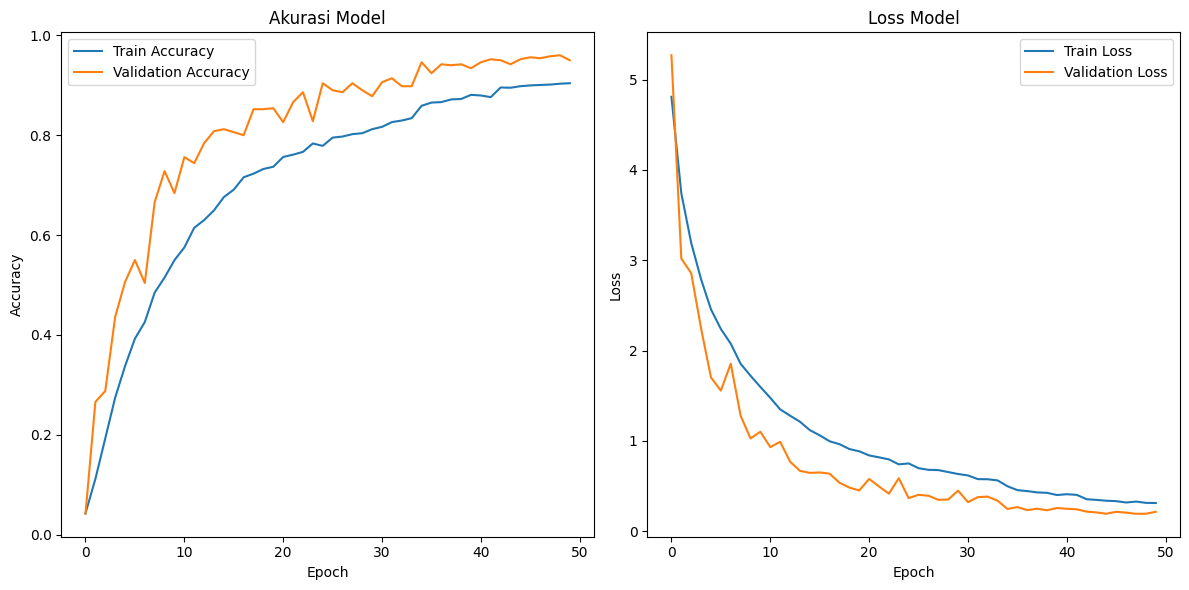

In [ ]:
# Evaluasi model pada data TEST
test_loss, test_accuracy = model.evaluate(test_generator, steps=len(test_generator), verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

# Visualisasi Akurasi dan Loss
history_dict = history.history

plt.figure(figsize=(12, 6))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history_dict['accuracy'], label='Train Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.title('Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_dict['loss'], label='Train Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.title('Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Konversi Model

In [ ]:
keras_model_path = "/content/drive/MyDrive/models/best_model.keras"
model = load_model(keras_model_path)

In [ ]:
# Path tujuan
saved_model_dir = '/content/drive/MyDrive/Submission/saved_model'
os.makedirs(saved_model_dir, exist_ok=True)

# Simpan model
model.export(saved_model_dir)
print("✅ Model disimpan dalam format SavedModel di:", saved_model_dir)

Saved artifact at '/content/drive/MyDrive/Submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 100), dtype=tf.float32, name=None)
Captures:
  137319826552400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137319826554704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137319826538768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137319826552208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137319826547600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137319826553552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137319826554320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137319671891536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137319671891728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137319671890960: TensorSpec(shape=(), dtype=tf.resourc

In [ ]:
# Path
saved_model_dir = '/content/drive/MyDrive/Submission/saved_model'
tflite_dir = '/content/drive/MyDrive/Submission/tflite'
os.makedirs(tflite_dir, exist_ok=True)

# Konversi
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# Simpan model TFLite
tflite_path = os.path.join(tflite_dir, 'model.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

# Salin label file
os.system(f'cp class_names.txt {os.path.join(tflite_dir, "label.txt")}')

print("✅ Model berhasil dikonversi ke format TFLite dan disimpan di:", tflite_dir)


✅ Model berhasil dikonversi ke format TFLite dan disimpan di: /content/drive/MyDrive/Submission/tflite


In [ ]:
# Path
saved_model_dir = '/content/drive/MyDrive/Submission/saved_model'
tfjs_dir = '/content/drive/MyDrive/Submission/tfjs_model'
os.makedirs(tfjs_dir, exist_ok=True)

# Konversi ke TFJS
os.system(f'tensorflowjs_converter --input_format=tf_saved_model --output_format=tfjs_graph_model {saved_model_dir} {tfjs_dir}')

print("✅ Model berhasil dikonversi ke format TensorFlow.js dan disimpan di:", tfjs_dir)

✅ Model berhasil dikonversi ke format TensorFlow.js dan disimpan di: /content/drive/MyDrive/Submission/tfjs_model


## Inference (Optional)

Saving download (16).jpeg to download (16) (2).jpeg


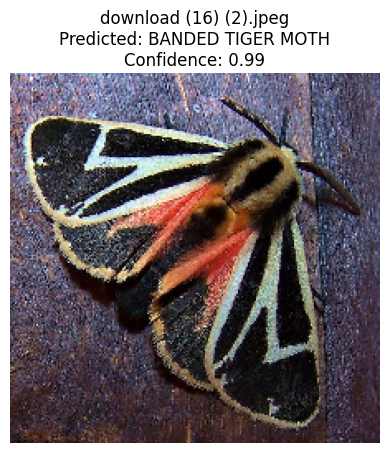

In [ ]:
# Path ke model dan labels
tflite_path = "/content/drive/MyDrive/Submission/tflite/model.tflite"
labels_path = "/content/drive/MyDrive/Submission/tflite/label.txt"

def tflite_inference(img_path, tflite_model_path, labels_path):
    # Load model
    interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
    interpreter.allocate_tensors()

    # Input/output detail
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # Load & preprocessing gambar
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Set dan jalankan inference
    interpreter.set_tensor(input_details[0]['index'], img_array)
    interpreter.invoke()

    # Output prediksi
    predictions = interpreter.get_tensor(output_details[0]['index'])
    pred_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][pred_class_idx]

    # Load label
    with open(labels_path, 'r') as f:
        labels = [line.strip() for line in f.readlines() if line.strip() != '']

    # Validasi index prediksi
    if pred_class_idx >= len(labels):
        print(f"[Warning] Predicted index {pred_class_idx} di luar jumlah label ({len(labels)}).")
        return f"Unknown (index {pred_class_idx})", confidence, img

    return labels[pred_class_idx], confidence, img

# Upload gambar dari lokal
uploaded = files.upload()

# Lakukan inference untuk setiap gambar yang diupload
for filename in uploaded.keys():
    pred_class, confidence, img = tflite_inference(filename, tflite_path, labels_path)

    # Tampilkan hasil
    plt.figure()
    plt.imshow(img)
    plt.title(f"{filename}\nPredicted: {pred_class}\nConfidence: {confidence:.2f}")
    plt.axis('off')
    plt.show()